In [1]:
import numpy as np
import pandas as pd

In [3]:
# read the 2 hour auctions-impression-click data
data = pd.read_csv(r"C:\Users\Chand\Downloads\pranjal_data\Mingao Analysis\Topsort-Online-Ads\2-hour auctions.csv")

In [4]:
import pandas as pd

# 1. Inspect data types
print("=== Column Data Types ===")
print(data.dtypes)
print()

# 2. Check a few unique values for non-numeric columns
print("=== Sample Unique Values for Object Columns ===")
for col in data.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(data[col].dropna().unique()[:5])  # show first 5 unique non-null values
print()

# 3. Check missing value summary
print("=== Missing Values Summary ===")
print(data.isna().mean().sort_values(ascending=False))

# 4. Optional cleaning for time columns
# Convert to datetime if not already
for tcol in ['IMPRESSION_TIME', 'CLICK_TIME', 'AUCTION_TIME']:
    if tcol in data.columns:
        data[tcol] = pd.to_datetime(data[tcol], errors='coerce')

# 5. Re-check the data types after cleaning
print("\n=== Data Types After Cleaning ===")
print(data.dtypes)


=== Column Data Types ===
AUCTION_ID_N        object
CAMPAIGN_ID_N       object
PRODUCT_ID_N        object
VENDOR_ID_N         object
AUCTION_TIME        object
RANKING              int64
IS_WINNER             bool
QUALITY            float64
FINAL_BID            int64
AUCTION_PRICE      float64
CONVERSION_RATE    float64
PACING             float64
OPAQUE_USER_ID      object
PLACEMENT            int64
IMPRESSION_TIME     object
CLICK_TIME          object
CLICK_ID            object
USER_ID             object
dtype: object

=== Sample Unique Values for Object Columns ===

AUCTION_ID_N:
['068433b09e587397b204f2a9c698eb52' '068433bab22471318204040385b31dd6'
 '068433b9405f7e5e8c04d060e05476a7' '068433c064a17de5a904066571df3ba6'
 '068433c2f9677c7284044af84c4b1c56']

CAMPAIGN_ID_N:
['0197376ba2007373bf77b22c32958d78' '019736bbda8770b3b535275699cfb002'
 '019733b2918078729736df577ee2b8f5' '01972c5be80470b2bf81ec0230f79685'
 '01973ca363aa7c70bf0c141de74c4563']

PRODUCT_ID_N:
['66bba1874fab7bd0bbe

In [8]:
# --- 1. Filter only rows where ad was shown (winner) and has an impression ---
df_ctr = data[(data['IS_WINNER'] == True) & (data['IMPRESSION_TIME'].notna())].copy()

# --- 2. Create an indicator for whether a click occurred ---
df_ctr['HAS_CLICK'] = df_ctr['CLICK_TIME'].notna().astype(int)

# --- 3. Group by ranking and compute CTR (mean of HAS_CLICK) ---
ctr_by_rank = (
    df_ctr.groupby('RANKING')['HAS_CLICK']
    .mean()
    .reset_index(name='CTR')
    .sort_values('RANKING')
)

# --- 4. Display ---
ctr_by_rank

,RANKING,CTR
0,1,0.028598
1,2,0.022412
2,3,0.025241
3,4,0.025018
4,5,0.024821
5,6,0.025161
6,7,0.024736
7,8,0.024286
8,9,0.023325
9,10,0.023746


In [9]:
# --- 1. Filter to only winning rows (eligible to be shown) ---
df_imp = data[data['IS_WINNER'] == True].copy()

# --- 2. Indicator for whether impression occurred ---
df_imp['HAS_IMPRESSION'] = df_imp['IMPRESSION_TIME'].notna().astype(int)

# --- 3. Group by ranking and compute probability of impression ---
impression_prob_by_rank = (
    df_imp.groupby('RANKING')['HAS_IMPRESSION']
    .mean()
    .reset_index(name='Impression_Prob')
    .sort_values('RANKING')
)

# --- 4. Display ---
impression_prob_by_rank

,RANKING,Impression_Prob
0,1,0.743982
1,2,0.754194
2,3,0.437200
3,4,0.429952
4,5,0.310856
5,6,0.307787
6,7,0.275792
7,8,0.274130
8,9,0.229696
9,10,0.226645


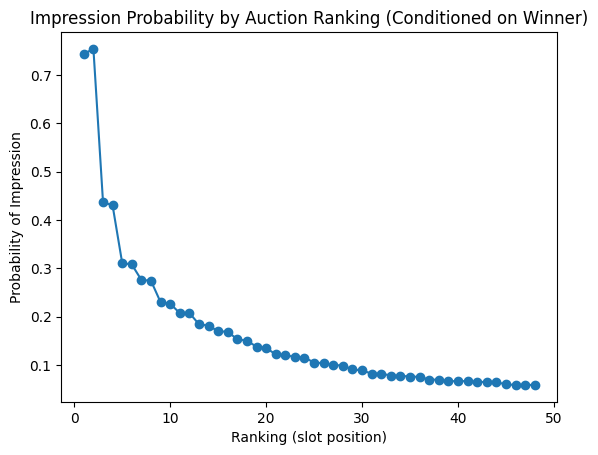

In [10]:
import matplotlib.pyplot as plt
plt.plot(impression_prob_by_rank['RANKING'], impression_prob_by_rank['Impression_Prob'], marker='o')
plt.xlabel("Ranking (slot position)")
plt.ylabel("Probability of Impression")
plt.title("Impression Probability by Auction Ranking (Conditioned on Winner)")
plt.show()

In [13]:
# Merge impression probability and CTR tables on ranking
df_ref = (
    impression_prob_by_rank
    .merge(ctr_by_rank, on='RANKING', how='outer')
    .rename(columns={'Impression_Prob': 'imp_prob'})
    .sort_values('RANKING')
    .reset_index(drop=True)
)

df_ref.to_csv("df_ref.csv", index=False)